In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Настройка стиля графиков

In [2]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [3]:
from google.colab import files
uploaded = files.upload()


Saving orders.xlsx to orders.xlsx


In [4]:
from google.colab import files
uploaded = files.upload()


Saving products.xlsx to products.xlsx


Загружаем данные

In [6]:

products = pd.read_excel('products.xlsx')
orders = pd.read_excel('orders.xlsx')




Просматриваем первые строки, смотрим данные, проверяем размер

In [7]:

print("=== Products (первые 5 строк) ===")
display(products.head())

print("\n=== Orders (первые 5 строк) ===")
display(orders.head())

print("\n=== Products Info ===")
print(products.info())

print("\n=== Orders Info ===")
print(orders.info())

print(f"\nProducts: {products.shape[0]} строк, {products.shape[1]} колонок")
print(f"Orders: {orders.shape[0]} строк, {orders.shape[1]} колонок")

=== Products (первые 5 строк) ===


,product_id,level1,level2,name
0,1,Гигиена,Бритье,Кассеты для бритья Gillette Fusion ProGlide Po...
1,2,Мучные кондитерские изделия,Мучные кондитерские изделия,Печенье Бодрость
2,3,Мясная гастрономия,"Сосиски, сардельки",Сосиски Стародворье
3,4,Чай,Черный чай,Чай Азерчай
4,5,Безалкогольные напитки,Соковая продукция,Морс Valio



=== Orders (первые 5 строк) ===


,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74
1,1517430051,2022-01-13 16:46:53,17122,1,169,169,74
2,1517578174,2022-01-13 18:12:30,17122,1,169,169,74
3,1517466327,2022-01-13 15:11:12,22199,1,219,219,130
4,1517429157,2022-01-13 19:15:59,22199,1,219,219,130



=== Products Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40152 entries, 0 to 40151
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   product_id  40152 non-null  int64 
 1   level1      40152 non-null  object
 2   level2      40152 non-null  object
 3   name        39940 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.2+ MB
None

=== Orders Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3323 entries, 0 to 3322
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       3323 non-null   int64         
 1   accepted_at    3323 non-null   datetime64[ns]
 2   product_id     3323 non-null   int64         
 3   quantity       3323 non-null   int64         
 4   regular_price  3323 non-null   int64         
 5   price          3323 non-null   int64         
 6   cost_price     3323 non-null   int

Объединяем таблицы по product_id


In [8]:

df = orders.merge(products, on='product_id', how='left')

print(f"Объединенная таблица: {df.shape[0]} строк, {df.shape[1]} колонок")
print("\nПервые 5 строк объединенной таблицы:")
display(df.head())

Объединенная таблица: 3323 строк, 10 колонок

Первые 5 строк объединенной таблицы:


,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price,level1,level2,name
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан
1,1517430051,2022-01-13 16:46:53,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан
2,1517578174,2022-01-13 18:12:30,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан
3,1517466327,2022-01-13 15:11:12,22199,1,219,219,130,Сыры,Мягкие сыры,Сыр Самокат
4,1517429157,2022-01-13 19:15:59,22199,1,219,219,130,Сыры,Мягкие сыры,Сыр Самокат


Провеярем есть ли товары без категории

In [9]:

missing_products = df['level1'].isna().sum()
print(f"\nЗаписей без категории: {missing_products}")


Записей без категории: 305


Убираем товары, которых нет в products


In [10]:

df = df[df['level1'].notna()]
print(f"После фильтрации: {df.shape[0]} строк")

После фильтрации: 3018 строк


Преобразуем accepted_at в формат datetime и проверяю диапазон дат


In [11]:

df['accepted_at'] = pd.to_datetime(df['accepted_at'])

print(f"Диапазон дат: {df['accepted_at'].min()} - {df['accepted_at'].max()}")
print(f"Уникальных дат: {df['accepted_at'].dt.date.nunique()}")

Диапазон дат: 2022-01-13 08:00:30 - 2022-01-13 22:58:29
Уникальных дат: 1


Задание 1: Самая ходовая товарная группа.
Проводим группировку по категории (level1) и суммируем количество, выводим результат в таблицу и визуализируем через барчарт с подписями, отдельно вывели лидера

 Продажи по категориям (по убыванию):
                      level1  quantity
      Безалкогольные напитки       534
          Молочная продукция       483
                Свежие овощи       262
                   Кулинария       250
                     Бакалея       239
Хлеб и хлебобулочные изделия       218
                       Снэки       212
               Свежие фрукты       184
      Замороженная продукция       175
        Кондитерские изделия       138
 Мучные кондитерские изделия       124
                        Сыры       114
      Продукция для животных       113
          Мясная гастрономия       112
             Детское питание        96
                       Птица        90
                     Гигиена        77
   Консервированные продукты        74
          Рыбная гастрономия        44
               Яичные товары        40
                         Чай        40
                        Мясо        29
                        Уход        24
               Бытовая хим

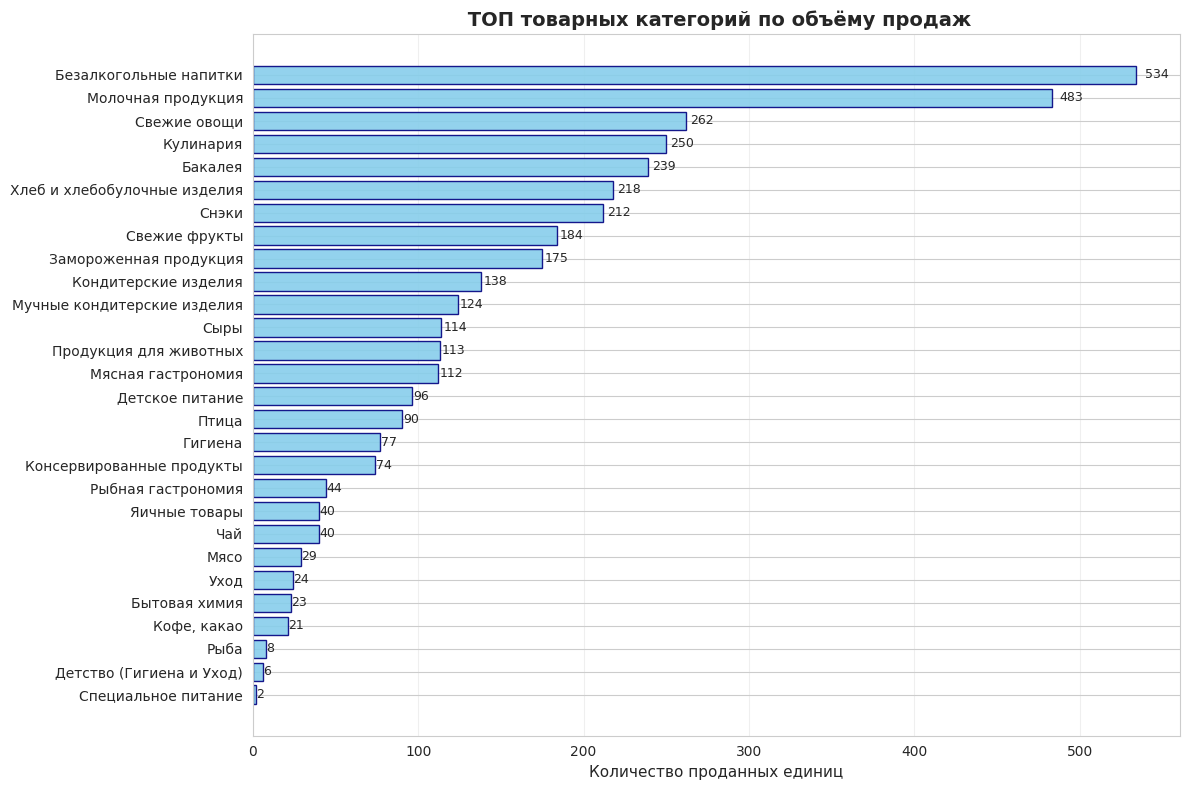


✅ Лидер продаж: 'Безалкогольные напитки' — 534 единиц


In [12]:

category_sales = df.groupby('level1')['quantity'].sum().reset_index()
category_sales = category_sales.sort_values('quantity', ascending=False)

print(" Продажи по категориям (по убыванию):")
print(category_sales.to_string(index=False))


plt.figure(figsize=(12, 8))
bars = plt.barh(category_sales['level1'], category_sales['quantity'],
                color='skyblue', edgecolor='navy', alpha=0.9)
plt.xlabel('Количество проданных единиц', fontsize=11)
plt.title(' ТОП товарных категорий по объёму продаж', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)


for bar in bars:
    width = bar.get_width()
    plt.text(width + width*0.01, bar.get_y() + bar.get_height()/2,
             f'{int(width):,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


leader = category_sales.iloc[0]
print(f"\n✅ Лидер продаж: '{leader['level1']}' — {leader['quantity']:,} единиц")

Задание 2: Распределение продаж по подкатегориям
Нужно посмотреть, как внутри каждой категории (level1) распределяются продажи по подкатегориям (level2).Для этого сгруппируем по категории и подкатегории и создадим сводную таблицу для наглядности


In [13]:

subcategory_sales = df.groupby(['level1', 'level2'])['quantity'].sum().reset_index()

pivot_table = subcategory_sales.pivot_table(
    index='level1',
    columns='level2',
    values='quantity',
    fill_value=0,
    aggfunc='sum'
)

print("Распределение продаж по подкатегориям внутри категорий:")
print("=" * 80)
display(pivot_table)

Распределение продаж по подкатегориям внутри категорий:


level2,"Бананы, косточковые и прочие плоды",Бараночные и сухарные изделия,Бритье,Бумажная продукция,Влажные салфетки,Воды минеральные,Воды питьевые,Восточные сладости,Все для суши,Готовая еда Самокат,...,Уход за кожей лица,Уход за одеждой и обувью,Хлеб и хлебобулочные изделия,Хлебцы,"Цитрусовые, семечковые и прочие плоды",Чайные напитки,Черный чай,Шоколад,Шоколадные конфеты в коробках,Яйцо куриное
level1,,,,,,,,,,,,,,,,,,,,,
Бакалея,0,0,0,0,0,0,0,0,9,0,...,0,0,0,0,0,0,0,0,0,0
Безалкогольные напитки,0,0,0,0,0,38,162,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Бытовая химия,0,0,0,0,0,0,0,0,0,0,...,0,3,0,0,0,0,0,0,0,0
Гигиена,0,0,3,42,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Детское питание,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Детство (Гигиена и Уход),0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Замороженная продукция,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Кондитерские изделия,0,0,0,0,0,0,0,3,0,0,...,0,0,0,0,0,0,0,29,3,0
Консервированные продукты,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Задание 3: Средний чек на 13.01.2022

Для этого фильтруем данные по дате 13.01.2022, рассчитываем сумму каждого чека: цена * количество, группируем по номеру заказа и суммируем позиции в чеке


In [15]:

target_date = '2022-01-13'
orders_date = df[df['accepted_at'].dt.date == pd.to_datetime(target_date).date()].copy()

orders_date['line_sum'] = orders_date['price'] * orders_date['quantity']

check_sums = orders_date.groupby('order_id')['line_sum'].sum()

average_check = check_sums.mean()

print(f'Средний чек {target_date}: {average_check:,.2f} ₽')

Средний чек 2022-01-13: 825.88 ₽


Задание 4: Доля промо в категории "Сыры".
Отфильтруем категорию "Сыры" и определим промо-продажи: regular_price != price
посчитаем в штуках и долях.

Строим pie chart




 Категория 'Сыры':
  Промо: 35 шт. (30.7%)
  Без промо: 79 шт. (69.3%)
  Всего: 114 шт.


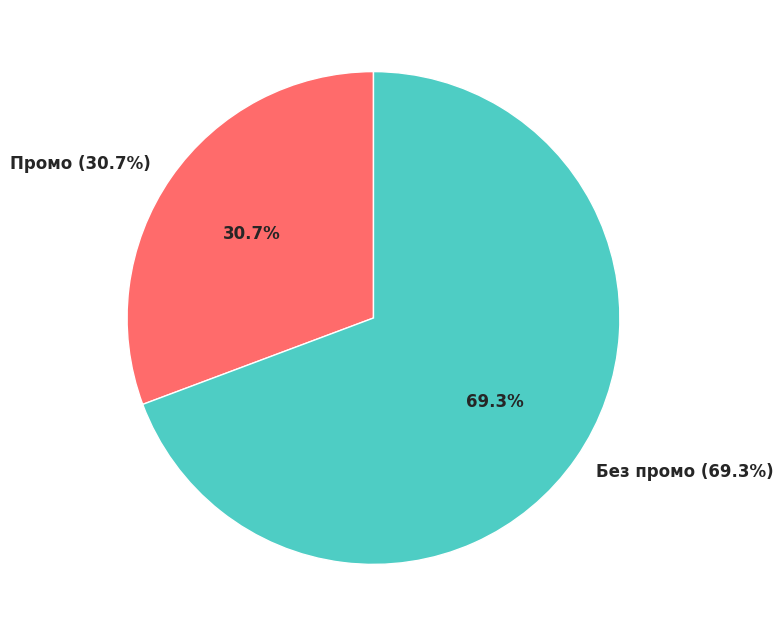

In [16]:

cheese_df = df[df['level1'] == 'Сыры'].copy()

cheese_df['is_promo'] = cheese_df['regular_price'] != cheese_df['price']

promo_qty = cheese_df[cheese_df['is_promo']]['quantity'].sum()
regular_qty = cheese_df[~cheese_df['is_promo']]['quantity'].sum()
total_qty = promo_qty + regular_qty

promo_share = promo_qty / total_qty * 100 if total_qty > 0 else 0
regular_share = regular_qty / total_qty * 100 if total_qty > 0 else 0

print(f" Категория 'Сыры':")
print(f"  Промо: {promo_qty:,} шт. ({promo_share:.1f}%)")
print(f"  Без промо: {regular_qty:,} шт. ({regular_share:.1f}%)")
print(f"  Всего: {total_qty:,} шт.")


plt.figure(figsize=(8, 8))
colors = ['#ff6b6b', '#4ecdc4']
labels = [f'Промо ({promo_share:.1f}%)', f'Без промо ({regular_share:.1f}%)']
sizes = [promo_qty, regular_qty]

wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 12, 'weight': 'bold'}
)


Задание 5. Посчитать маржу по категориям
Для этого рассчитываем выручку, себестоимость и маржу, группируем по категориям
и строим графикив рублях и процентах




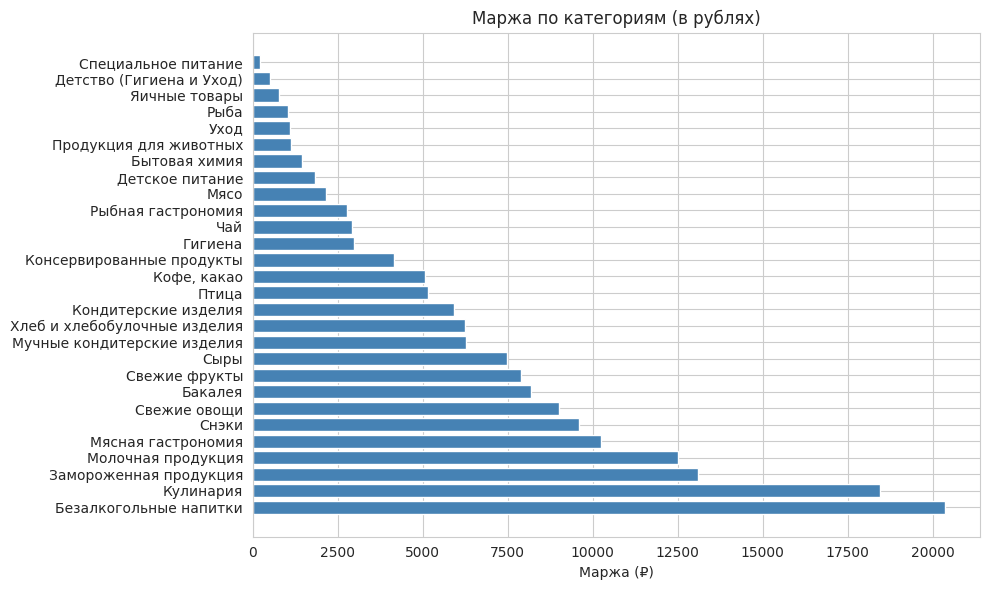

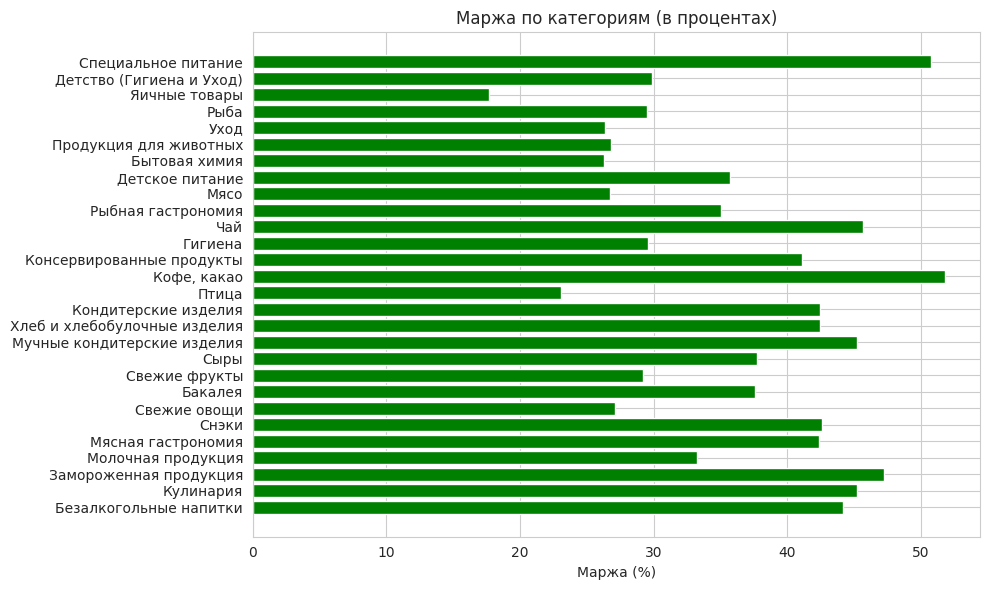

                      level1  margin_rub  margin_pct
         Специальное питание         208       50.73
    Детство (Гигиена и Уход)         517       29.90
               Яичные товары         781       17.67
                        Рыба        1021       29.51
                        Уход        1099       26.33
      Продукция для животных        1113       26.77
               Бытовая химия        1441       26.31
             Детское питание        1817       35.69
                        Мясо        2150       26.70
          Рыбная гастрономия        2765       35.03
                         Чай        2929       45.67
                     Гигиена        2971       29.55
   Консервированные продукты        4154       41.12
                 Кофе, какао        5059       51.83
                       Птица        5153       23.06
        Кондитерские изделия        5918       42.45
Хлеб и хлебобулочные изделия        6251       42.45
 Мучные кондитерские изделия        6283      

In [17]:

df['revenue'] = df['price'] * df['quantity']
df['cost'] = df['cost_price'] * df['quantity']
df['margin_rub'] = df['revenue'] - df['cost']
df['margin_pct'] = (df['margin_rub'] / df['revenue']) * 100

margin_by_cat = df.groupby('level1').agg({
    'margin_rub': 'sum',
    'revenue': 'sum'
}).reset_index()
margin_by_cat['margin_pct'] = (margin_by_cat['margin_rub'] / margin_by_cat['revenue']) * 100
margin_by_cat = margin_by_cat.sort_values('margin_rub')

plt.figure(figsize=(10, 6))
plt.barh(margin_by_cat['level1'], margin_by_cat['margin_rub'], color='steelblue')
plt.xlabel('Маржа (₽)')
plt.title('Маржа по категориям (в рублях)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in margin_by_cat['margin_pct']]
plt.barh(margin_by_cat['level1'], margin_by_cat['margin_pct'], color=colors)
plt.xlabel('Маржа (%)')
plt.title('Маржа по категориям (в процентах)')
plt.gca().invert_yaxis()
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print(margin_by_cat[['level1', 'margin_rub', 'margin_pct']].round(2).to_string(index=False))

АВС анализ.
1.ABC-анализ продаж по количеству:
-группируем данные по подкатегориям (level2)
-считаем сумму проданных единиц по каждой подкатегории
-сортируем от большего к меньшему
-считаем накопительную долю
-присваивает группы: A (0-80%), B (80-95%), C (95-100%)


In [18]:

abc_qty = df.groupby('level2')['quantity'].sum().reset_index()

abc_qty = abc_qty.sort_values('quantity', ascending=False)

abc_qty['cumulative_qty'] = abc_qty['quantity'].cumsum()

total_qty = abc_qty['quantity'].sum()
abc_qty['cumulative_pct'] = abc_qty['cumulative_qty'] / total_qty * 100

def assign_abc_group(pct):
    if pct <= 80:
        return 'A'
    elif pct <= 95:
        return 'B'
    else:
        return 'C'

abc_qty['abc_group'] = abc_qty['cumulative_pct'].apply(assign_abc_group)

print("="*80)
print("ABC-АНАЛИЗ ПО КОЛИЧЕСТВУ ПРОДАЖ")
print("="*80)
print(f"\nВсего подкатегорий: {len(abc_qty)}")
print(f"Общее количество проданных единиц: {total_qty:,}")
print(f"\nРаспределение по группам:")
print(f"  Группа A: {len(abc_qty[abc_qty['abc_group']=='A'])} подкатегорий")
print(f"  Группа B: {len(abc_qty[abc_qty['abc_group']=='B'])} подкатегорий")
print(f"  Группа C: {len(abc_qty[abc_qty['abc_group']=='C'])} подкатегорий")

print("\n" + "="*80)
print("ТОП-20 ПОДКАТЕГОРИЙ (ABC-анализ по количеству)")
print("="*80)
display(abc_qty[['level2', 'quantity', 'cumulative_pct', 'abc_group']].head(20))

ABC-АНАЛИЗ ПО КОЛИЧЕСТВУ ПРОДАЖ

Всего подкатегорий: 100
Общее количество проданных единиц: 3,732

Распределение по группам:
  Группа A: 30 подкатегорий
  Группа B: 28 подкатегорий
  Группа C: 42 подкатегорий

ТОП-20 ПОДКАТЕГОРИЙ (ABC-анализ по количеству)


,level2,quantity,cumulative_pct,abc_group
51,Напитки,252,6.752412,A
10,Готовые блюда,248,13.397642,A
92,Хлеб и хлебобулочные изделия,218,19.239014,A
72,Снэки соленые,180,24.062165,A
6,Воды питьевые,162,28.403001,A
33,"Корнеплоды, зелень и прочие овощи",157,32.609861,A
40,Молоко и сливки,147,36.548767,A
41,Молочно-десертные продукты,116,39.657020,A
94,"Цитрусовые, семечковые и прочие плоды",108,42.550911,A
26,Кисломолочные традиционные продукты,106,45.391211,A


ABC-анализ по сумме продаж:
создаем колонку sales_amount = price × quantity
группируем по подкатегориям и считает общую сумму продаж
сортируем от большей суммы к меньшей
считаем накопительную долю и присваиваем группы: A (0-80%), B (80-95%), C (95-100%)


In [19]:

df['sales_amount'] = df['price'] * df['quantity']

abc_sales = df.groupby('level2')['sales_amount'].sum().reset_index()

abc_sales = abc_sales.sort_values('sales_amount', ascending=False)

abc_sales['cumulative_sales'] = abc_sales['sales_amount'].cumsum()

total_sales = abc_sales['sales_amount'].sum()
abc_sales['cumulative_pct'] = abc_sales['cumulative_sales'] / total_sales * 100

abc_sales['abc_group'] = abc_sales['cumulative_pct'].apply(
    lambda pct: 'A' if pct <= 80 else ('B' if pct <= 95 else 'C')
)

print("="*80)
print("ABC-АНАЛИЗ ПО СУММЕ ПРОДАЖ")
print("="*80)

group_a = len(abc_sales[abc_sales['abc_group']=='A'])
group_b = len(abc_sales[abc_sales['abc_group']=='B'])
group_c = len(abc_sales[abc_sales['abc_group']=='C'])

print(f"\nРаспределение по группам:")
print(f"  Группа A: {group_a} подкатегорий")
print(f"  Группа B: {group_b} подкатегорий")
print(f"  Группа C: {group_c} подкатегорий")

print("\n" + "="*80)
print("ТОП-20 ПОДКАТЕГОРИЙ (ABC-анализ по сумме продаж)")
print("="*80)
display(abc_sales[['level2', 'sales_amount', 'cumulative_pct', 'abc_group']].head(20).round(2))

print("\n" + "="*80)
print("АУТСАЙДЕРЫ (последние 10 подкатегорий)")
print("="*80)
display(abc_sales[['level2', 'sales_amount', 'cumulative_pct', 'abc_group']].tail(10).round(2))

ABC-АНАЛИЗ ПО СУММЕ ПРОДАЖ

Распределение по группам:
  Группа A: 32 подкатегорий
  Группа B: 30 подкатегорий
  Группа C: 38 подкатегорий

ТОП-20 ПОДКАТЕГОРИЙ (ABC-анализ по сумме продаж)


,level2,sales_amount,cumulative_pct,abc_group
10,Готовые блюда,40356,9.03,A
51,Напитки,24123,14.43,A
50,Мясо птицы охлажденное,22349,19.43,A
85,"Тепличные овощи, грибы",18329,23.54,A
72,Снэки соленые,17293,27.41,A
94,"Цитрусовые, семечковые и прочие плоды",16818,31.17,A
18,Замороженные полуфабрикаты,15374,34.61,A
40,Молоко и сливки,14902,37.95,A
33,"Корнеплоды, зелень и прочие овощи",14893,41.28,A
92,Хлеб и хлебобулочные изделия,14724,44.57,A



АУТСАЙДЕРЫ (последние 10 подкатегорий)


,level2,sales_amount,cumulative_pct,abc_group
46,Мыло туалетное,335,99.52,C
82,Субпродуктовые изделия,324,99.59,C
47,Мытье посуды,306,99.66,C
61,Попкорн,304,99.73,C
4,Влажные салфетки,255,99.79,C
77,Средства для сантехники,239,99.84,C
24,"Какао, горячий шоколад",238,99.89,C
91,Уход за одеждой и обувью,235,99.95,C
57,Первая помощь,168,99.98,C
71,Снэки сладкие,75,100.00,C
